In [1]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np

In [2]:
df_full = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = df_full.copy()

In [21]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [22]:
df_a = df_X[["userId", "song", "artist"]].drop_duplicates()

In [23]:
df_a = df_a.groupby("userId").size().reset_index()

In [24]:
df_a

,userId,0
0,1000035,706
1,1000103,53
2,1000164,351
3,1000168,343
4,1000182,283
...,...,...
15428,1999241,245
15429,1999382,33
15430,1999781,1837
15431,1999848,399


In [18]:
df_b = df_a.merge(df_y, on = "userId")

In [17]:
df_b

,userId,num_different_songs,Cancellation Confirmation
0,1000035,706,0
1,1000103,53,0
2,1000164,351,0
3,1000168,343,0
4,1000182,283,0
...,...,...,...
15428,1999241,245,0
15429,1999382,33,0
15430,1999781,1837,0
15431,1999848,399,0


In [9]:
import seaborn as sns

<Axes: xlabel='Cancellation Confirmation', ylabel='num_different_songs'>

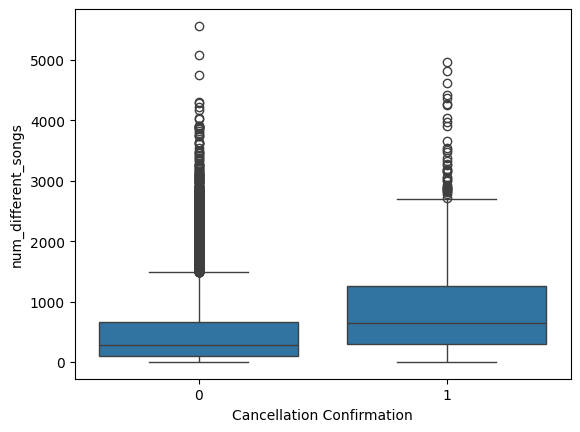

In [10]:
sns.boxplot(df_b, x = "Cancellation Confirmation", y = "num_different_songs")

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
df_b

X = df_b[["num_different_songs"]]
y = df_b["Cancellation Confirmation"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

clf = HistGradientBoostingClassifier()

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

confusion_matrix(y_test, y_pred)

array([[3685,    0],
       [ 174,    0]])